In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cycler
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import scipy.stats as st

In [13]:
def get_cycle(cmap, N=None, use_index="auto"):
    if isinstance(cmap, str):
        if use_index == "auto":
            if cmap in ['Pastel1', 'Pastel2', 'Paired', 'Accent',
                        'Dark2', 'Set1', 'Set2', 'Set3',
                        'tab10', 'tab20', 'tab20b', 'tab20c']:
                use_index=True
            else:
                use_index=False
        cmap = plt.get_cmap(cmap)
    if not N:
        N = cmap.N
    if use_index=="auto":
        if cmap.N > 100:
            use_index=False
        elif isinstance(cmap, LinearSegmentedColormap):
            use_index=False
        elif isinstance(cmap, ListedColormap):
            use_index=True
    if use_index:
        ind = np.arange(int(N)) % cmap.N
        return cycler("color",cmap(ind))
    else:
        colors = cmap(np.linspace(0,1,N))
        return cycler("color",colors)

def set_style():
    plt.style.use('default')
    default_cycler=cycler(color=['mediumorchid','teal','navy','firebrick','goldenrod','slategrey'])
    plt.rc('axes', prop_cycle=default_cycler)
    
    plt.rcParams['font.family'] = 'STIXGeneral'  # Closely matches Computer Modern
    plt.rcParams['mathtext.fontset'] = 'stix'    # Use STIX for math
    
    plt.rcParams['axes.titlesize'] = 16
    plt.rcParams['axes.labelsize'] = 14
    plt.rcParams['xtick.labelsize'] = 12
    plt.rcParams['ytick.labelsize'] = 12
    
    return

In [14]:
set_style()

In [8]:
## just trying to confirm my suspicions w.r.t. the error inference
true_dist = st.norm(loc=0,scale=2)

In [9]:
data = true_dist.rvs(5000,random_state=10)

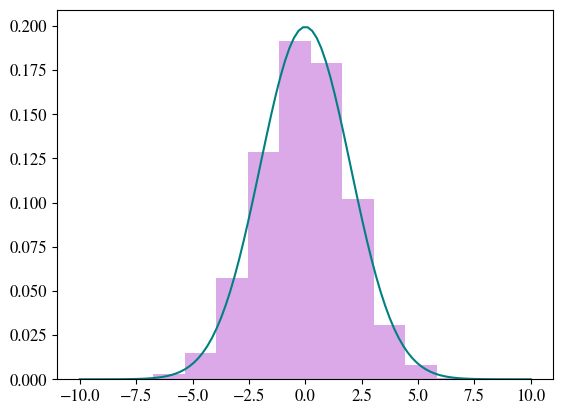

In [16]:
xs = np.linspace(-10,10,100)
plt.figure()
plt.hist(data,density=True,alpha=0.5)
plt.plot(xs,true_dist.pdf(xs))
plt.show()

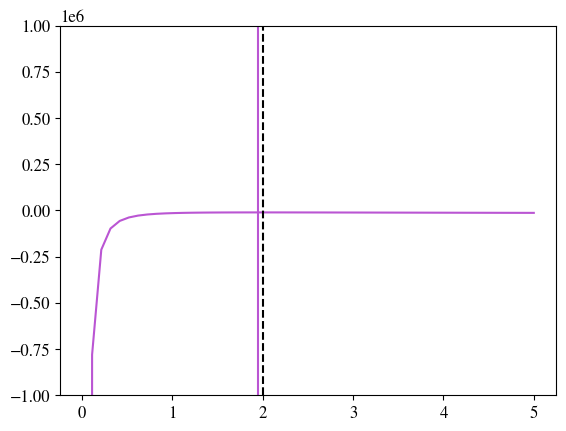

In [24]:
loglike = np.empty(50)
sigmas = np.linspace(0.01,5,50)
for ii in range(len(loglike)):
    loglike[ii] = np.sum(st.norm.logpdf(data,loc=0,scale=sigmas[ii]))
plt.figure()
plt.plot(sigmas,loglike)
plt.axvline(2,ls='--',c='k')
plt.axvline(sigmas[np.argmax(loglike)])
plt.ylim(-1e6,1e6)
plt.show()

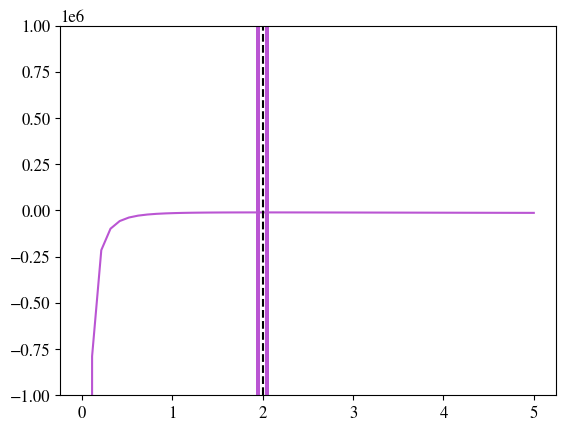

In [25]:
loglike = np.empty(50)
sigmas = np.linspace(0.01,5,50)
plt.figure()
for ii in range(1000):
    data = true_dist.rvs(5000)
    for ii in range(len(loglike)):
        loglike[ii] = np.sum(st.norm.logpdf(data,loc=0,scale=sigmas[ii]))
    plt.axvline(sigmas[np.argmax(loglike)],alpha=0.1)
plt.plot(sigmas,loglike)
plt.axvline(2,ls='--',c='k')
plt.ylim(-1e6,1e6)
plt.show()

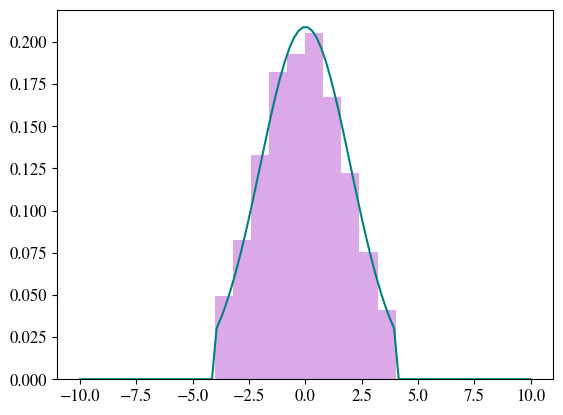

In [35]:
true_dist_2 = st.truncnorm(-2,2,loc=0,scale=2)
truncdata = true_dist_2.rvs(size=5000,random_state=10)
xs = np.linspace(-10,10,100)
plt.figure()
plt.hist(truncdata,density=True,alpha=0.5)
plt.plot(xs,true_dist_2.pdf(xs))
plt.show()

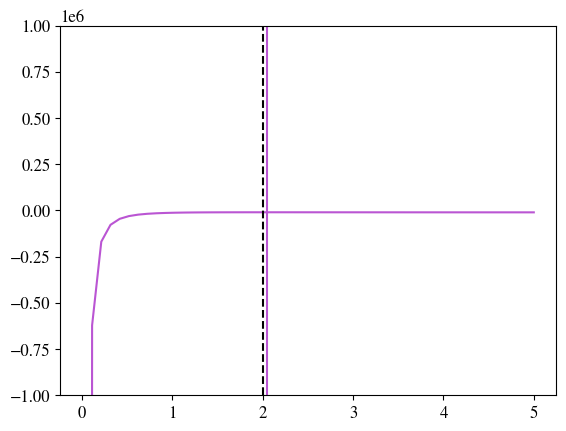

In [36]:
loglike = np.empty(50)
sigmas = np.linspace(0.01,5,50)
for ii in range(len(loglike)):
    a_new = -4/sigmas[ii]
    b_new = 4/sigmas[ii]
    loglike[ii] = np.sum(st.truncnorm.logpdf(truncdata,a_new,b_new,loc=0,scale=sigmas[ii]))
plt.figure()
plt.plot(sigmas,loglike)
plt.axvline(2,ls='--',c='k')
plt.axvline(sigmas[np.argmax(loglike)])
plt.ylim(-1e6,1e6)
plt.show()

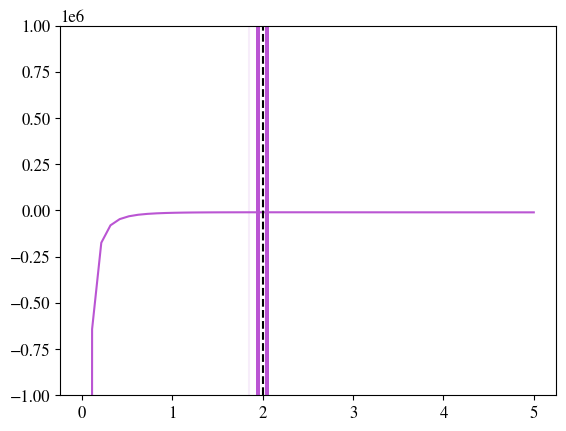

In [37]:
loglike = np.empty(50)
sigmas = np.linspace(0.01,5,50)
plt.figure()
for jj in range(1000):
    data = true_dist_2.rvs(5000)
    for ii in range(len(loglike)):
        a_new = -4/sigmas[ii]
        b_new = 4/sigmas[ii]
        loglike[ii] = np.sum(st.truncnorm.logpdf(data,a_new,b_new,loc=0,scale=sigmas[ii]))
    plt.axvline(sigmas[np.argmax(loglike)],alpha=0.1)
plt.plot(sigmas,loglike)
plt.axvline(2,ls='--',c='k')
plt.ylim(-1e6,1e6)
plt.show()